In [5]:
# 01_burst_regimes.ipynb
# Compare single spikes, non-overlapping bursts, and overlapping bursts.

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Let this notebook import from src/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import (
    make_sleep_like_sequence,
    make_burst_sequence,
    burst_overlap_duration,
)

from src.dendrite import (
    simulate_dendrite,
    score_detection,
    plot_input_raster,
    plot_voltage_traces,
    plot_ampa_conductances,
)


# Shared setup
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 90.0
dt = 0.02

G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0

start_time = 10.0
weight = 1.0


def score_sequence_order(
    times,
    V_hist,
    sequence_segments,
    threshold=0.0,
    min_step_separation_ms=1.0,
):
    """Score whether activation is truly sequential."""
    score = score_detection(
        times,
        V_hist,
        sequence_segments=sequence_segments,
        threshold=threshold,
    )

    activation_times = score["activation_times"]
    act_values = [activation_times[int(seg)] for seg in sequence_segments]

    all_detected = all(np.isfinite(x) for x in act_values)

    if all_detected:
        step_separations = np.diff(act_values)
        separated = np.all(step_separations >= min_step_separation_ms)
    else:
        step_separations = np.array([])
        separated = False

    score["step_separations"] = step_separations
    score["separated"] = bool(separated)
    score["sequence_success"] = bool(score["success"] and separated)

    return score


def print_sequence_score(score):
    """Print the score in a compact way."""
    print("regular success:", score["success"])
    print("sequence success:", score["sequence_success"])
    print("ordered:", score["ordered"])
    print("separated:", score["separated"])
    print("final voltage:", round(score["final_voltage"], 3))
    print("activation times:", score["activation_times"])
    print("step separations:", np.round(score["step_separations"], 3))


def run_condition(name, events, raster):
    """Run one condition and show the main plots."""
    print("=" * 60)
    print(name)
    print("=" * 60)

    plot_input_raster(raster, title=f"{name}: input raster")

    times, V_hist = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA,
        G_KIR=G_KIR,
        G_ax=G_ax,
        ampa_events=events,
    )

    plot_voltage_traces(
        times,
        V_hist,
        segments_to_plot=sequence_segments,
        title=f"{name}: voltage traces",
    )

    plot_ampa_conductances(
        times,
        n_segments,
        events,
        title=f"{name}: AMPA conductances",
    )

    score = score_sequence_order(
        times,
        V_hist,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    print_sequence_score(score)

    return times, V_hist, score

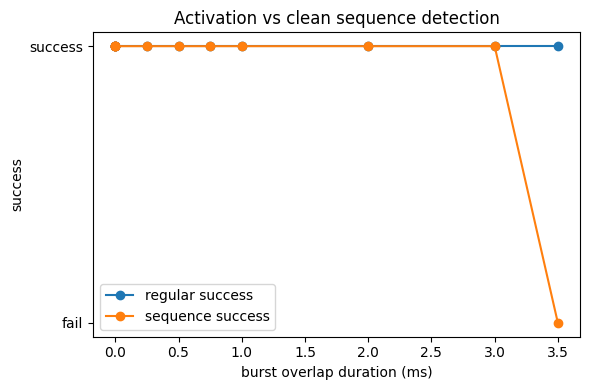

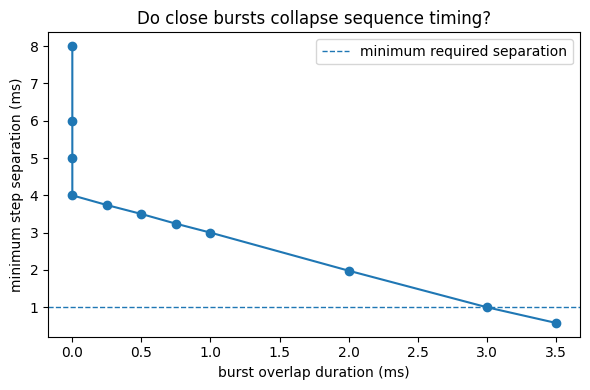

Overlap sweep summary
------------------------------------------------------------
onset step = 8.0 ms | overlap = 0.0 ms | regular success = True | sequence success = True | min separation = 8.0 ms | final voltage = 0.909
onset step = 6.0 ms | overlap = 0.0 ms | regular success = True | sequence success = True | min separation = 6.0 ms | final voltage = 0.909
onset step = 5.0 ms | overlap = 0.0 ms | regular success = True | sequence success = True | min separation = 5.0 ms | final voltage = 0.909
onset step = 4.0 ms | overlap = 0.0 ms | regular success = True | sequence success = True | min separation = 4.0 ms | final voltage = 0.909
onset step = 3.75 ms | overlap = 0.25 ms | regular success = True | sequence success = True | min separation = 3.74 ms | final voltage = 0.909
onset step = 3.5 ms | overlap = 0.5 ms | regular success = True | sequence success = True | min separation = 3.5 ms | final voltage = 0.909
onset step = 3.25 ms | overlap = 0.75 ms | regular success = True | sequen

In [7]:
# Sweep burst spacing
# Smaller onset_step_ms means bursts are closer/more overlapping.
# We include 3.5 ms because this is where we observed failure.

onset_steps = np.array([8.0, 6.0, 5.0, 4.0, 3.75, 3.5, 3.25, 3.0, 2.0, 1.0, 0.5])

overlaps = []
regular_successes = []
sequence_successes = []
final_voltages = []
min_step_separations = []

for onset_step in onset_steps:
    events, raster = make_burst_sequence(
        sequence_segments=sequence_segments,
        start_time=start_time,
        onset_step_ms=float(onset_step),
        burst_len=burst_len,
        isi_ms=isi_ms,
        weight=weight,
    )

    times, V_hist = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA,
        G_KIR=G_KIR,
        G_ax=G_ax,
        ampa_events=events,
    )

    score = score_sequence_order(
        times,
        V_hist,
        sequence_segments=sequence_segments,
        threshold=0.0,
        min_step_separation_ms=1.0,
    )

    overlap = burst_overlap_duration(
        onset_step_ms=float(onset_step),
        burst_len=burst_len,
        isi_ms=isi_ms,
    )

    if len(score["step_separations"]) > 0:
        min_sep = float(np.min(score["step_separations"]))
    else:
        min_sep = np.nan

    overlaps.append(overlap)
    regular_successes.append(score["success"])
    sequence_successes.append(score["sequence_success"])
    final_voltages.append(score["final_voltage"])
    min_step_separations.append(min_sep)


# Plot regular success vs sequence success
plt.figure(figsize=(6, 4))
plt.plot(overlaps, regular_successes, marker="o", label="regular success")
plt.plot(overlaps, sequence_successes, marker="o", label="sequence success")
plt.xlabel("burst overlap duration (ms)")
plt.ylabel("success")
plt.yticks([0, 1], ["fail", "success"])
plt.title("Activation vs clean sequence detection")
plt.legend()
plt.tight_layout()
plt.show()


# Plot timing separation
plt.figure(figsize=(6, 4))
plt.plot(overlaps, min_step_separations, marker="o")
plt.axhline(1.0, linestyle="--", linewidth=1, label="minimum required separation")
plt.xlabel("burst overlap duration (ms)")
plt.ylabel("minimum step separation (ms)")
plt.title("Do close bursts collapse sequence timing?")
plt.legend()
plt.tight_layout()
plt.show()


# Print sweep summary
print("Overlap sweep summary")
print("-" * 60)

for onset_step, overlap, reg_success, seq_success, final_v, min_sep in zip(
    onset_steps,
    overlaps,
    regular_successes,
    sequence_successes,
    final_voltages,
    min_step_separations,
):
    print(
        "onset step =",
        round(float(onset_step), 2),
        "ms | overlap =",
        round(overlap, 2),
        "ms | regular success =",
        reg_success,
        "| sequence success =",
        seq_success,
        "| min separation =",
        round(min_sep, 3),
        "ms | final voltage =",
        round(final_v, 3),
    )

onset step: 3.5 ms
burst overlap duration: 0.5 ms
Burst onset step = 3.5 ms


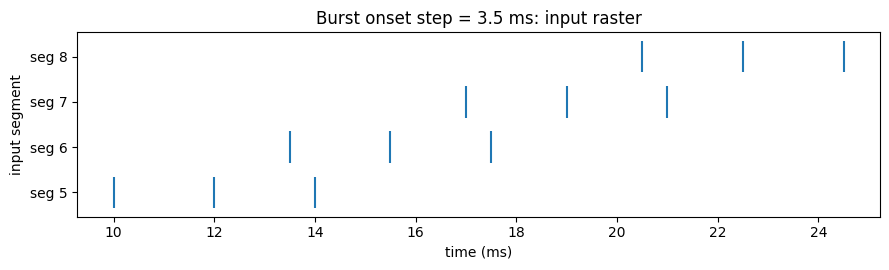

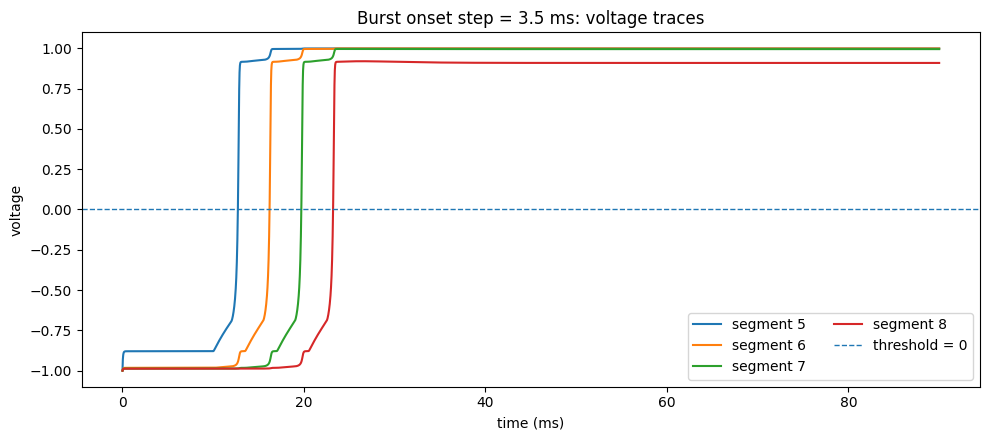

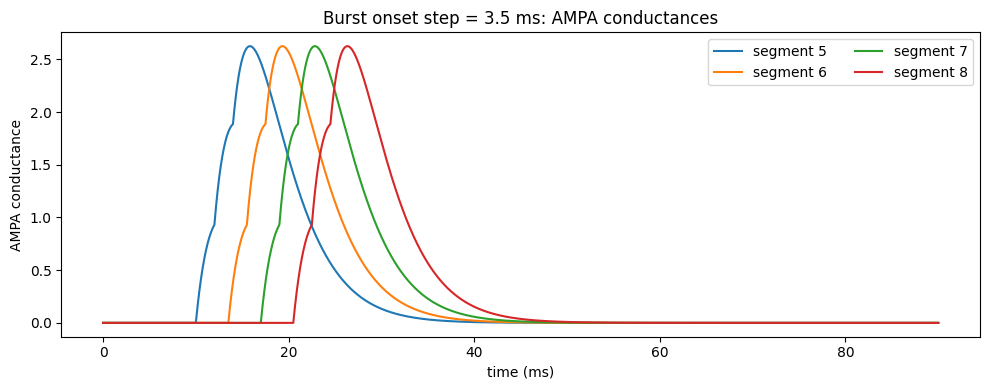

regular success: True
sequence success: True
ordered: True
separated: True
final voltage: 0.909
activation times: {5: 12.72, 6: 16.22, 7: 19.72, 8: 23.22}
step separations: [3.5 3.5 3.5]


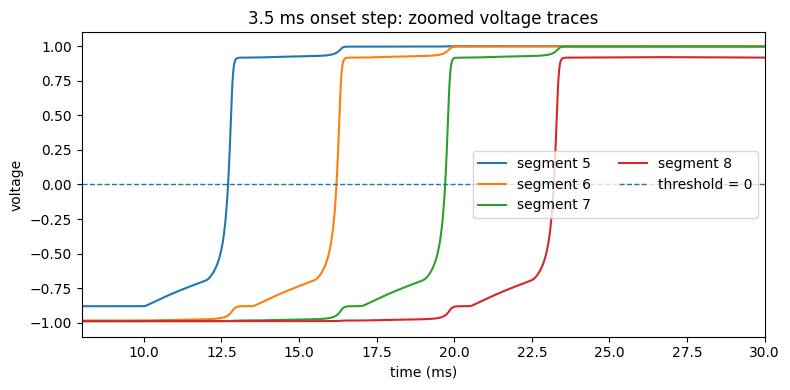

regular success: True
sequence success: True
ordered: True
separated: True
final voltage: 0.909
activation times: {5: 12.72, 6: 16.22, 7: 19.72, 8: 23.22}
step separations: [3.5 3.5 3.5]


In [ ]:
# Inspect the 3.5 ms overlap failure case
# Important: 3.5 ms here means overlap duration, not onset step.

target_overlap_ms = 3.5

burst_span_ms = (burst_len - 1) * isi_ms
test_step_ms = burst_span_ms - target_overlap_ms

print("burst span:", burst_span_ms, "ms")
print("target overlap:", target_overlap_ms, "ms")
print("onset step needed:", test_step_ms, "ms")

events_fail, raster_fail = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=test_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

times_fail, V_fail, score_fail = run_condition(
    "Failure case: 3.5 ms overlap",
    events_fail,
    raster_fail,
)

# Zoomed voltage plot

plt.figure(figsize=(8, 4))

for seg in sequence_segments:
    plt.plot(times_fail, V_fail[:, seg], label=f"segment {seg}")

plt.axhline(0, linestyle="--", linewidth=1, label="threshold = 0")
plt.xlim(8, 25)
plt.xlabel("time (ms)")
plt.ylabel("voltage")
plt.title("Failure case: 3.5 ms overlap")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

print_sequence_score(score_fail)